In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9627 - loss: 0.1249 - val_accuracy: 0.9826 - val_loss: 0.0534
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9877 - loss: 0.0416 - val_accuracy: 0.9864 - val_loss: 0.0411
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9890 - val_loss: 0.0308
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9899 - val_loss: 0.0301
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9947 - loss: 0.0157 - val_accuracy: 0.9902 - val_loss: 0.0286
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9902 - loss: 0.0286
Test Accuracy: 0.9901999831199646


In [ ]:
model.save("handwritten_character_model.h5")

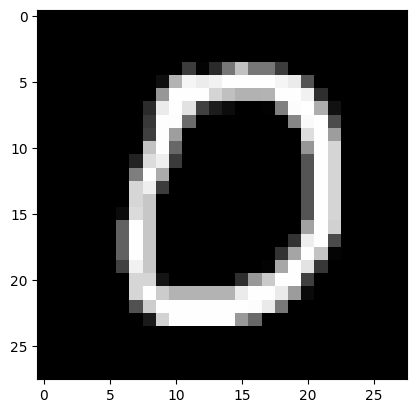

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Predicted Digit: 0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

index = 10

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28,1))
print("Predicted Digit:", np.argmax(prediction))

Saving hwimg.png to hwimg.png


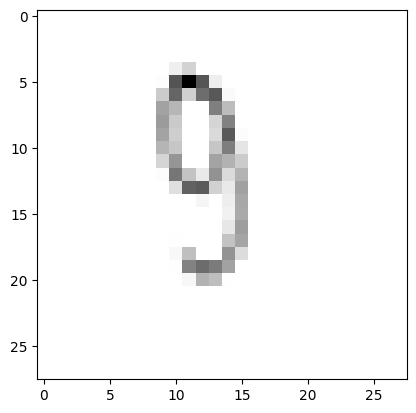

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Digit: 3
Confidence: 35.480057 %


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Resize to MNIST size
img = img.resize((28, 28))

# Show image
plt.imshow(img, cmap='gray')
plt.show()

# Preprocess
img_array = np.array(img)

# Invert colors if needed (MNIST = white digit on black background)
img_array = 255 - img_array

img_array = img_array / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img_array)
print("Predicted Digit:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100, "%")

In [ ]:
prediction = model.predict(img_array)
print(prediction)
print("Predicted Digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.0068508  0.09633034 0.10552766 0.35480055 0.06921053 0.04697333
  0.00162875 0.06256744 0.00380474 0.25230587]]
Predicted Digit: 3


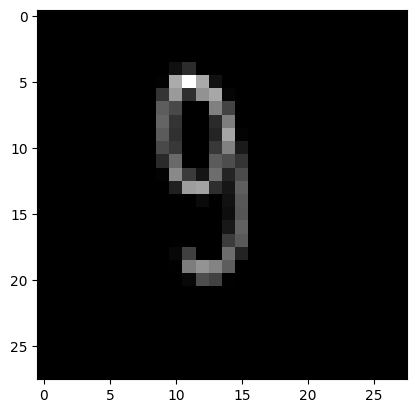

In [ ]:
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

In [ ]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9881 - val_loss: 0.0375
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9904 - val_loss: 0.0315
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9973 - loss: 0.0077 - val_accuracy: 0.9915 - val_loss: 0.0302
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9975 - loss: 0.0073 - val_accuracy: 0.9891 - val_loss: 0.0444
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 0.9906 - val_loss: 0.0369
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9901 - val_loss: 0.0395
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9984 - loss: 0.0041 - val_accuracy: 0.9878 - val_loss: 0.0611
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9984 -

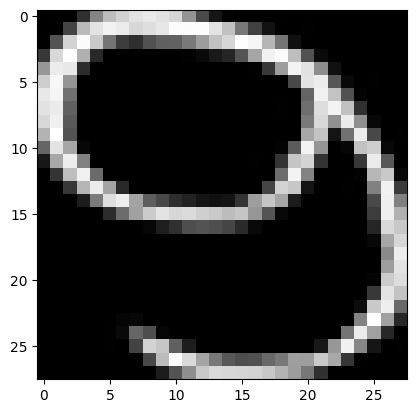

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Digit: 8
Probabilities: [[6.1100750e-13 5.2833091e-03 2.9842019e-02 3.9679726e-06 1.5639856e-01
  2.4461579e-09 8.5901888e-08 4.3448767e-06 8.0846775e-01 4.8020867e-09]]


In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open(filename).convert('L')

# Convert to numpy array
img_array = np.array(img)

# Find digit area
coords = np.argwhere(img_array < 200)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

# Crop around digit
img_array = img_array[y_min:y_max+1, x_min:x_max+1]

# Resize
img = Image.fromarray(img_array)
img = img.resize((28,28))

# Invert colors
img_array = 255 - np.array(img)

# Normalize
img_array = img_array / 255.0

# Display what model sees
plt.imshow(img_array, cmap='gray')
plt.show()

# Predict
img_array = img_array.reshape(1,28,28,1)

prediction = model.predict(img_array)
print("Predicted Digit:", np.argmax(prediction))
print("Probabilities:", prediction)

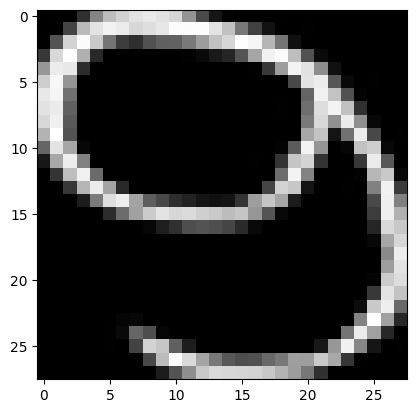

In [9]:
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

In [10]:
prediction = model.predict(img_array)
print(prediction[0])

for i, p in enumerate(prediction[0]):
    print(f"{i}: {p:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[6.1100750e-13 5.2833091e-03 2.9842019e-02 3.9679726e-06 1.5639856e-01
 2.4461579e-09 8.5901888e-08 4.3448767e-06 8.0846775e-01 4.8020867e-09]
0: 0.0000
1: 0.0053
2: 0.0298
3: 0.0000
4: 0.1564
5: 0.0000
6: 0.0000
7: 0.0000
8: 0.8085
9: 0.0000


Saving img.png to img.png


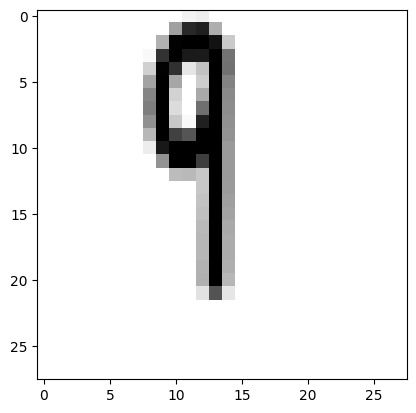

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Digit: 6
Confidence: 58.686646 %


In [11]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Resize to MNIST size
img = img.resize((28, 28))

# Show image
plt.imshow(img, cmap='gray')
plt.show()

# Preprocess
img_array = np.array(img)

# Invert colors if needed (MNIST = white digit on black background)
img_array = 255 - img_array

img_array = img_array / 255.0
img_array = img_array.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img_array)
print("Predicted Digit:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100, "%")

Saving hwimg.png to hwimg (1).png


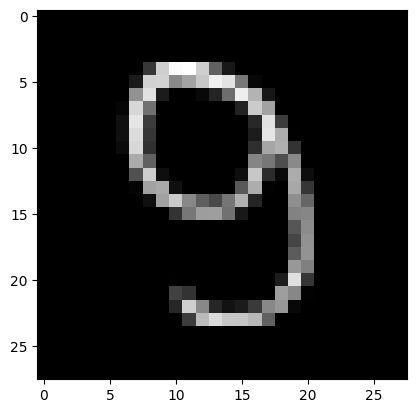

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Digit: 9
Confidence: 99.335205


In [12]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Invert: black digit on white -> white digit on black
img = ImageOps.invert(img)

# Crop digit
img_array = np.array(img)
coords = np.argwhere(img_array > 50)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

img_array = img_array[y_min:y_max+1, x_min:x_max+1]

# Make square
h, w = img_array.shape
size = max(h, w)

square = np.zeros((size, size), dtype=np.uint8)

y_offset = (size - h) // 2
x_offset = (size - w) // 2

square[y_offset:y_offset+h, x_offset:x_offset+w] = img_array

# Resize to 20x20
img = Image.fromarray(square)
img = img.resize((20, 20))

# Put in center of 28x28 canvas
canvas = np.zeros((28, 28), dtype=np.uint8)
canvas[4:24, 4:24] = np.array(img)

# Show what model sees
plt.imshow(canvas, cmap='gray')
plt.show()

# Predict
canvas = canvas.astype("float32") / 255.0
canvas = canvas.reshape(1, 28, 28, 1)

prediction = model.predict(canvas)

print("Predicted Digit:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100)

Saving img.png to img (1).png


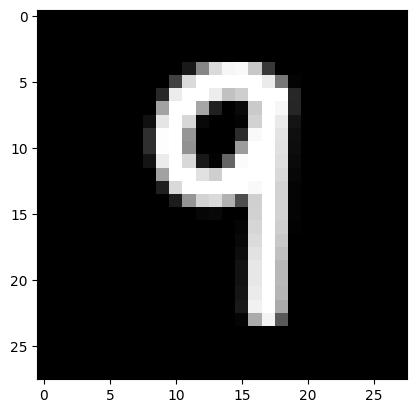

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Digit: 9
Confidence: 100.0


In [13]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Invert: black digit on white -> white digit on black
img = ImageOps.invert(img)

# Crop digit
img_array = np.array(img)
coords = np.argwhere(img_array > 50)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

img_array = img_array[y_min:y_max+1, x_min:x_max+1]

# Make square
h, w = img_array.shape
size = max(h, w)

square = np.zeros((size, size), dtype=np.uint8)

y_offset = (size - h) // 2
x_offset = (size - w) // 2

square[y_offset:y_offset+h, x_offset:x_offset+w] = img_array

# Resize to 20x20
img = Image.fromarray(square)
img = img.resize((20, 20))

# Put in center of 28x28 canvas
canvas = np.zeros((28, 28), dtype=np.uint8)
canvas[4:24, 4:24] = np.array(img)

# Show what model sees
plt.imshow(canvas, cmap='gray')
plt.show()

# Predict
canvas = canvas.astype("float32") / 255.0
canvas = canvas.reshape(1, 28, 28, 1)

prediction = model.predict(canvas)

print("Predicted Digit:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100)

Saving download.png to download.png


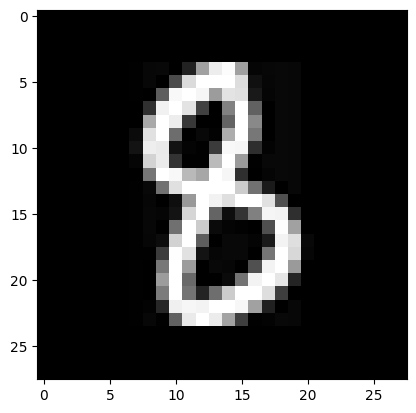

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Digit: 8
Confidence: 100.0


In [14]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Invert: black digit on white -> white digit on black
img = ImageOps.invert(img)

# Crop digit
img_array = np.array(img)
coords = np.argwhere(img_array > 50)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

img_array = img_array[y_min:y_max+1, x_min:x_max+1]

# Make square
h, w = img_array.shape
size = max(h, w)

square = np.zeros((size, size), dtype=np.uint8)

y_offset = (size - h) // 2
x_offset = (size - w) // 2

square[y_offset:y_offset+h, x_offset:x_offset+w] = img_array

# Resize to 20x20
img = Image.fromarray(square)
img = img.resize((20, 20))

# Put in center of 28x28 canvas
canvas = np.zeros((28, 28), dtype=np.uint8)
canvas[4:24, 4:24] = np.array(img)

# Show what model sees
plt.imshow(canvas, cmap='gray')
plt.show()

# Predict
canvas = canvas.astype("float32") / 255.0
canvas = canvas.reshape(1, 28, 28, 1)

prediction = model.predict(canvas)

print("Predicted Digit:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100)